In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1. Install Libarry

In [ ]:
!pip -q install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.6 MB/s eta 0:00:00


# 2. Import Library

In [ ]:
# General
import os
import re
import random
import string
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss
)

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

# Indonesian NLP
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings("ignore")


#3. Load Dataset

In [ ]:
## Lokasi Dataset

BASE_PATH = "/content/drive/MyDrive/Project Deep Learning/dataset"

DATASET_PATH = f"{BASE_PATH}/data.csv"

SLANG_PATH = f"{BASE_PATH}/new_kamusalay.csv"

STOPWORD_PATH = f"{BASE_PATH}/stopwordbahasa.csv"

In [ ]:
df = pd.read_csv(DATASET_PATH, encoding='latin1')

print("="*50)
print("Dataset Information")
print("="*50)

print(f"Jumlah Data  : {len(df):,}")
print(f"Jumlah Kolom : {len(df.columns)}")

Dataset Information
Jumlah Data  : 13,169
Jumlah Kolom : 13


In [ ]:
df.head()

,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet          13169 non-null  object
 1   HS             13169 non-null  int64 
 2   Abusive        13169 non-null  int64 
 3   HS_Individual  13169 non-null  int64 
 4   HS_Group       13169 non-null  int64 
 5   HS_Religion    13169 non-null  int64 
 6   HS_Race        13169 non-null  int64 
 7   HS_Physical    13169 non-null  int64 
 8   HS_Gender      13169 non-null  int64 
 9   HS_Other       13169 non-null  int64 
 10  HS_Weak        13169 non-null  int64 
 11  HS_Moderate    13169 non-null  int64 
 12  HS_Strong      13169 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 1.3+ MB


In [ ]:
df.describe(include="all")

,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
count,13169,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000
unique,13023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,USER USER USER USER USER USER USER USER USER U...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.422280,0.382945,0.271471,0.150809,0.060217,0.042980,0.024527,0.023236,0.284000,0.256891,0.129471,0.035918
std,NaN,0.493941,0.486123,0.444735,0.357876,0.237898,0.202819,0.154685,0.150659,0.450954,0.436935,0.335733,0.186092
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000


In [ ]:
df.isnull().sum()

,0
Tweet,0
HS,0
Abusive,0
HS_Individual,0
HS_Group,0
HS_Religion,0
HS_Race,0
HS_Physical,0
HS_Gender,0
HS_Other,0


#4. Exploratory Data Analysis

In [ ]:
# ==========================================================
# Memilih Kolom yang Digunakan
# ==========================================================

df = df[['Tweet', 'HS', 'Abusive']]

df.head()

,Tweet,HS,Abusive
0,- disaat semua cowok berusaha melacak perhatia...,1,1
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1


In [ ]:
print("Distribusi Hate Speech")
print(df['HS'].value_counts())

print("\nDistribusi Abusive")
print(df['Abusive'].value_counts())

Distribusi Hate Speech
HS
0    7608
1    5561
Name: count, dtype: int64

Distribusi Abusive
Abusive
0    8126
1    5043
Name: count, dtype: int64


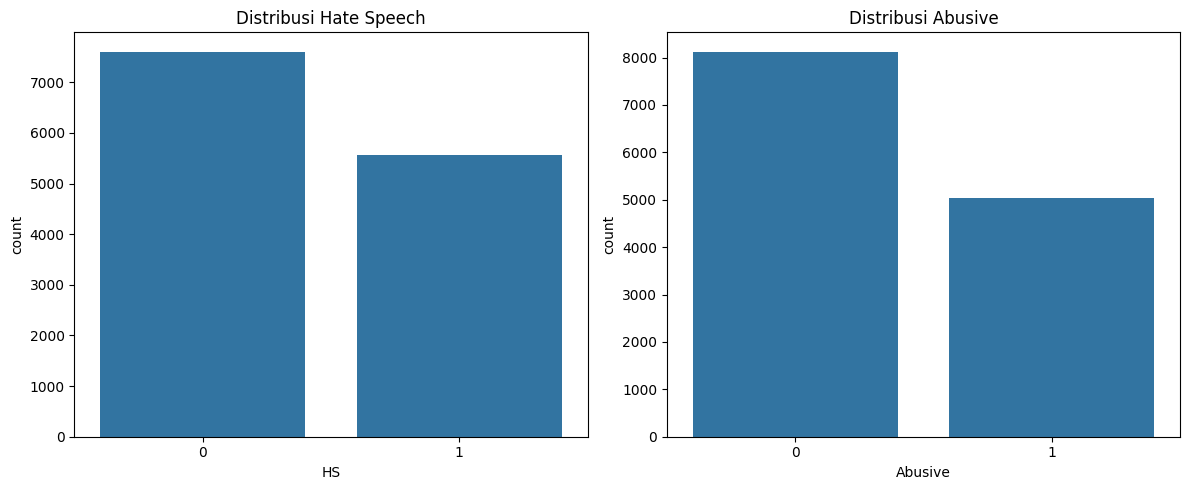

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(data=df, x='HS', ax=axes[0])
axes[0].set_title("Distribusi Hate Speech")

sns.countplot(data=df, x='Abusive', ax=axes[1])
axes[1].set_title("Distribusi Abusive")

plt.tight_layout()
plt.show()

# 4. Text Preprocessing


Tahapan preprocessing meliputi:

- Cleaning
- Case Folding
- Tokenization
- Normalisasi Kata
- Stopword Removal

##4.1. Cleaning

In [ ]:
# ==========================================================
# Cleaning Text
# ==========================================================

def clean_text(text):

    text = str(text)

    # URL
    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub('RT',' ',text) # Remove every retweet symbol
    text = re.sub('USER',' ',text) # Remove every username

    # Mention
    text = re.sub(r'@\w+', '', text)

    # Hashtag (# saja dihapus, katanya tetap dipertahankan)
    text = re.sub(r'#', '', text)

    # Angka
    text = re.sub(r'\d+', '', text)

    # Tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Spasi berlebih
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
df["clean_text"] = df["Tweet"].apply(clean_text)

In [ ]:
df[["Tweet","clean_text"]].head(10)

,Tweet,clean_text
0,- disaat semua cowok berusaha melacak perhatia...,disaat semua cowok berusaha melacak perhatian ...
1,RT USER: USER siapa yang telat ngasih tau elu?...,siapa yang telat ngasih tau eluedan sarap gue ...
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",Kadang aku berfikir kenapa aku tetap percaya p...
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,AKU ITU AKUnnKU TAU MATAMU SIPIT TAPI DILIAT D...
4,USER USER Kaum cebong kapir udah keliatan dong...,Kaum cebong kapir udah keliatan dongoknya dari...
5,USER Ya bani taplak dkk \xf0\x9f\x98\x84\xf0\x...,Ya bani taplak dkk xfxfxxxfxfxxxfxfxx
6,deklarasi pilkada 2018 aman dan anti hoax warg...,deklarasi pilkada aman dan anti hoax warga duk...
7,Gue baru aja kelar re-watch Aldnoah Zero!!! pa...,Gue baru aja kelar rewatch Aldnoah Zero paling...
8,Nah admin belanja satu lagi port terbaik nak m...,Nah admin belanja satu lagi port terbaik nak m...
9,USER Enak lg klo smbil ngewe',Enak lg klo smbil ngewe


##4.2. Case Folding

In [ ]:
def case_folding(text):
    return text.lower()

In [ ]:
df["case_fold"] = df["clean_text"].apply(case_folding)

In [ ]:
df[["clean_text","case_fold"]].head()

,clean_text,case_fold
0,disaat semua cowok berusaha melacak perhatian ...,disaat semua cowok berusaha melacak perhatian ...
1,siapa yang telat ngasih tau eluedan sarap gue ...,siapa yang telat ngasih tau eluedan sarap gue ...
2,Kadang aku berfikir kenapa aku tetap percaya p...,kadang aku berfikir kenapa aku tetap percaya p...
3,AKU ITU AKUnnKU TAU MATAMU SIPIT TAPI DILIAT D...,aku itu akunnku tau matamu sipit tapi diliat d...
4,Kaum cebong kapir udah keliatan dongoknya dari...,kaum cebong kapir udah keliatan dongoknya dari...


##4.3. Tokenisasi

In [ ]:
# ==========================================================
# Tokenization
# ==========================================================
nltk.download('punkt_tab')
df["tokens"] = df["case_fold"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df[["case_fold", "tokens"]].head(10)

,case_fold,tokens
0,disaat semua cowok berusaha melacak perhatian ...,"[disaat, semua, cowok, berusaha, melacak, perh..."
1,siapa yang telat ngasih tau eluedan sarap gue ...,"[siapa, yang, telat, ngasih, tau, eluedan, sar..."
2,kadang aku berfikir kenapa aku tetap percaya p...,"[kadang, aku, berfikir, kenapa, aku, tetap, pe..."
3,aku itu akunnku tau matamu sipit tapi diliat d...,"[aku, itu, akunnku, tau, matamu, sipit, tapi, ..."
4,kaum cebong kapir udah keliatan dongoknya dari...,"[kaum, cebong, kapir, udah, keliatan, dongokny..."
5,ya bani taplak dkk xfxfxxxfxfxxxfxfxx,"[ya, bani, taplak, dkk, xfxfxxxfxfxxxfxfxx]"
6,deklarasi pilkada aman dan anti hoax warga duk...,"[deklarasi, pilkada, aman, dan, anti, hoax, wa..."
7,gue baru aja kelar rewatch aldnoah zero paling...,"[gue, baru, aja, kelar, rewatch, aldnoah, zero..."
8,nah admin belanja satu lagi port terbaik nak m...,"[nah, admin, belanja, satu, lagi, port, terbai..."
9,enak lg klo smbil ngewe,"[enak, lg, klo, smbil, ngewe]"


##4.4. Normalisasi

In [ ]:
kamus_alay = pd.read_csv(
    SLANG_PATH,
    encoding="latin1",
    header=None,
    names=["slang", "formal"]
)

kamus_alay.head()

,slang,formal
0,anakjakartaasikasik,anak jakarta asyik asyik
1,pakcikdahtua,pak cik sudah tua
2,pakcikmudalagi,pak cik muda lagi
3,t3tapjokowi,tetap jokowi
4,3x,tiga kali


In [ ]:
slang_dict = dict(zip(kamus_alay["slang"], kamus_alay["formal"]))

print(f"Jumlah kata slang : {len(slang_dict):,}")

Jumlah kata slang : 15,167


In [ ]:
def normalize_tokens(tokens):
    """
    Mengubah kata slang menjadi kata baku
    menggunakan kamus normalisasi.
    """
    return [slang_dict.get(word, word) for word in tokens]

In [ ]:
df["normalized_tokens"] = df["tokens"].apply(normalize_tokens)

In [ ]:
df[["tokens", "normalized_tokens"]].head(10)

,tokens,normalized_tokens
0,"[disaat, semua, cowok, berusaha, melacak, perh...","[di saat, semua, cowok, berusaha, melacak, per..."
1,"[siapa, yang, telat, ngasih, tau, eluedan, sar...","[siapa, yang, telat, memberi, tau, eluedan, sa..."
2,"[kadang, aku, berfikir, kenapa, aku, tetap, pe...","[kadang, aku, berpikir, kenapa, aku, tetap, pe..."
3,"[aku, itu, akunnku, tau, matamu, sipit, tapi, ...","[aku, itu, akunnku, tau, matamu, sipit, tapi, ..."
4,"[kaum, cebong, kapir, udah, keliatan, dongokny...","[kaum, cebong, kafir, sudah, kelihatan, dongok..."
5,"[ya, bani, taplak, dkk, xfxfxxxfxfxxxfxfxx]","[ya, bani, taplak, dan kawan kawan, xfxfxxxfxf..."
6,"[deklarasi, pilkada, aman, dan, anti, hoax, wa...","[deklarasi, pilihan kepala daerah, aman, dan, ..."
7,"[gue, baru, aja, kelar, rewatch, aldnoah, zero...","[gue, baru, saja, selesai, rewatch, aldnoah, z..."
8,"[nah, admin, belanja, satu, lagi, port, terbai...","[nah, admin, belanja, satu, lagi, port, terbai..."
9,"[enak, lg, klo, smbil, ngewe]","[enak, lagi, kalau, sambil, ngewe]"


##4.5 Stopword Removal

In [ ]:
# ==========================================================
# Load Stopword
# ==========================================================

stopword_df = pd.read_csv(
    STOPWORD_PATH,
    header=None,
    names=["stopword"]
)

stopwords_set = set(stopword_df["stopword"].astype(str))

print(f"Jumlah stopword : {len(stopwords_set)}")

Jumlah stopword : 757


In [ ]:
def remove_stopwords(tokens):
    """
    Menghapus stopword dari daftar token.
    """
    return [
        word for word in tokens
        if word not in stopwords_set
    ]

In [ ]:
df["filtered_tokens"] = df["normalized_tokens"].apply(remove_stopwords)

In [ ]:
df[
    [
        "normalized_tokens",
        "filtered_tokens"
    ]
].head(10)

,normalized_tokens,filtered_tokens
0,"[di saat, semua, cowok, berusaha, melacak, per...","[di saat, cowok, berusaha, melacak, perhatian,..."
1,"[siapa, yang, telat, memberi, tau, eluedan, sa...","[telat, tau, eluedan, sarap, gue, bergaul, cig..."
2,"[kadang, aku, berpikir, kenapa, aku, tetap, pe...","[kadang, berpikir, percaya, tuhan, jatuh, berk..."
3,"[aku, itu, akunnku, tau, matamu, sipit, tapi, ...","[akunnku, tau, matamu, sipit]"
4,"[kaum, cebong, kafir, sudah, kelihatan, dongok...","[kaum, cebong, kafir, dongoknya, dungu, haha]"
5,"[ya, bani, taplak, dan kawan kawan, xfxfxxxfxf...","[ya, bani, taplak, dan kawan kawan, xfxfxxxfxf..."
6,"[deklarasi, pilihan kepala daerah, aman, dan, ...","[deklarasi, pilihan kepala daerah, aman, anti,..."
7,"[gue, baru, saja, selesai, rewatch, aldnoah, z...","[gue, selesai, rewatch, aldnoah, zero, kampret..."
8,"[nah, admin, belanja, satu, lagi, port, terbai...","[admin, belanja, port, terbaik, nak, makan, ai..."
9,"[enak, lagi, kalau, sambil, ngewe]","[enak, ngewe]"


## 4.6. Hasil Preprocessing

In [ ]:
# ==========================================================
# Dataset Hasil Preprocessing
# ==========================================================

# Join filtered tokens back into a single string
df["final_text"] = df["filtered_tokens"].apply(lambda x: ' '.join(x))

preprocessed_df = df[[
    "final_text",
    "HS",
    "Abusive"
]]

preprocessed_df.head()

,final_text,HS,Abusive
0,di saat cowok berusaha melacak perhatian gue l...,1,1
1,telat tau eluedan sarap gue bergaul cigax jifl...,0,1
2,kadang berpikir percaya tuhan jatuh berkalikal...,0,0
3,akunnku tau matamu sipit,0,0
4,kaum cebong kafir dongoknya dungu haha,1,1


In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/Project Deep Learning/output"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
##preprocessed_df.to_csv(
 ##   f"{OUTPUT_PATH}/preprocessed_dataset.csv",
 ##   index=False,
 ##   encoding="utf-8"
##)

##print("Dataset berhasil disimpan.")

#5. GLOVE Word Embedding

In [ ]:
glove_df = pd.read_csv(
    f"{OUTPUT_PATH}/preprocessed_dataset.csv"
)

glove_df.head()

,final_text,HS,Abusive
0,di saat cowok berusaha melacak perhatian gue l...,1,1
1,telat tau eluedan sarap gue bergaul cigax jifl...,0,1
2,kadang berpikir percaya tuhan jatuh berkalikal...,0,0
3,akunnku tau matamu sipit,0,0
4,kaum cebong kafir dongoknya dungu haha,1,1


##5.1. Splitting Dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# ==========================================================
# Split Train dan Temporary
# ==========================================================

train_df, temp_df = train_test_split(
    glove_df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

print("Train :", len(train_df))
print("Temp  :", len(temp_df))

Train : 9218
Temp  : 3951


In [ ]:
# ==========================================================
# Split Validation dan Test
# ==========================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=2/3,
    random_state=42,
    shuffle=True
)

print("Validation :", len(val_df))
print("Test       :", len(test_df))

Validation : 1317
Test       : 2634


In [ ]:
total = len(glove_df)

print(f"Total Data : {total}")

print(f"Train      : {len(train_df)} ({len(train_df)/total:.2%})")
print(f"Validation : {len(val_df)} ({len(val_df)/total:.2%})")
print(f"Test       : {len(test_df)} ({len(test_df)/total:.2%})")

Total Data : 13169
Train      : 9218 (70.00%)
Validation : 1317 (10.00%)
Test       : 2634 (20.00%)


In [ ]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

##5.2. Hitung Frekuensi Kata

In [ ]:
from collections import Counter

# ==========================================================
# Build Vocabulary
# ==========================================================

word_counter = Counter()

for sentence in train_df["final_text"]:
    word_counter.update(str(sentence).split())

print(f"Jumlah kata unik : {len(word_counter):,}")

Jumlah kata unik : 19,238


### Vocabulary dengan PAD dan UNK

In [ ]:
# ==========================================================
# Vocabulary
# ==========================================================

word_to_id = {
    "<PAD>": 0,
    "<UNK>": 1
}

id_to_word = {
    0: "<PAD>",
    1: "<UNK>"
}

for word in word_counter.keys():

    if word not in word_to_id:

        idx = len(word_to_id)

        word_to_id[word] = idx
        id_to_word[idx] = word

In [ ]:
# ==========================================================
# Integer Encoding
# ==========================================================

def encode_sentence(sentence):

    return [

        word_to_id.get(word, word_to_id["<UNK>"])

        for word in str(sentence).split()

    ]

In [ ]:
train_df["encoded"] = train_df["final_text"].apply(encode_sentence)

val_df["encoded"] = val_df["final_text"].apply(encode_sentence)

test_df["encoded"] = test_df["final_text"].apply(encode_sentence)

In [ ]:
print(train_df["encoded"].iloc[789])

[1564, 73, 1859, 3651, 500, 1326, 2178, 13, 14, 15]


##5.3. Co-Occurence Matrix

In [ ]:
from collections import defaultdict

# ==========================================================
# Build Co-occurrence Matrix
# ==========================================================

cooccurrence = defaultdict(float)

for sentence in train_df["encoded"]:

    sentence_length = len(sentence)

    for center_index, center_word in enumerate(sentence):

        left = max(0, center_index - WINDOW_SIZE)
        right = min(sentence_length, center_index + WINDOW_SIZE + 1)

        for context_index in range(left, right):

            if center_index == context_index:
                continue

            context_word = sentence[context_index]

            distance = abs(center_index - context_index)

            weight = 1.0 / distance

            cooccurrence[(center_word, context_word)] += weight

In [ ]:
print(f"Jumlah pasangan kata : {len(cooccurrence):,}")

Jumlah pasangan kata : 509,886


In [ ]:
cooccurrence_items = list(cooccurrence.items())

for pair, value in cooccurrence_items[:20]:
    print(pair, "->", round(value, 3))

(2, 3) -> 1.0
(3, 2) -> 1.0
(4, 5) -> 1.0
(4, 6) -> 0.5
(4, 7) -> 0.333
(4, 8) -> 0.45
(4, 9) -> 0.2
(5, 4) -> 1.0
(5, 6) -> 2.0
(5, 7) -> 1.0
(5, 8) -> 0.667
(5, 9) -> 0.25
(5, 10) -> 0.2
(6, 4) -> 0.5
(6, 5) -> 2.0
(6, 7) -> 3.0
(6, 8) -> 1.0
(6, 9) -> 0.333
(6, 10) -> 0.25
(6, 11) -> 0.2


##5.4. Convert ke DataFrame

In [ ]:
import pandas as pd

# ==========================================================
# Convert Co-occurrence ke DataFrame
# ==========================================================

cooccurrence_df = pd.DataFrame(
    [
        (center, context, x_ij)
        for (center, context), x_ij in cooccurrence.items()
    ],
    columns=["center_id", "context_id", "x_ij"]
)

cooccurrence_df.head()

,center_id,context_id,x_ij
0,2,3,1.000000
1,3,2,1.000000
2,4,5,1.000000
3,4,6,0.500000
4,4,7,0.333333


In [ ]:
# ==========================================================
# Ukuran Vocabulary
# ==========================================================

VOCAB_SIZE = len(word_to_id)

print(f"Vocabulary Size : {VOCAB_SIZE:,}")

Vocabulary Size : 19,240


##5.5. Pytorch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================================
# PyTorch Dataset
# ==========================================================

class GloVeDataset(Dataset):

    def __init__(self, dataframe):

        self.center_ids = torch.LongTensor(
            dataframe["center_id"].values
        )

        self.context_ids = torch.LongTensor(
            dataframe["context_id"].values
        )

        self.xij = torch.FloatTensor(
            dataframe["x_ij"].values
        )

    def __len__(self):
        return len(self.center_ids)

    def __getitem__(self, idx):

        return (
            self.center_ids[idx],
            self.context_ids[idx],
            self.xij[idx]
        )

In [ ]:
glove_dataset = GloVeDataset(cooccurrence_df)

print("Jumlah pasangan kata :", len(glove_dataset))

Jumlah pasangan kata : 509886


In [ ]:
BATCH_SIZE = 1024

train_loader = DataLoader(
    glove_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [ ]:
center, context, xij = next(iter(train_loader))

print(center.shape)
print(context.shape)
print(xij.shape)

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


##5.6 Model GLOVE

In [ ]:
# ==========================================================
# Hyperparameter GloVe
# ==========================================================

X_MAX = 100
ALPHA = 0.75

In [ ]:
# ==========================================================
# Weighting Function
# Persamaan (9)
# ==========================================================

def weighting_function(x):
    """
    Menghitung bobot pasangan kata berdasarkan
    Persamaan (9) pada paper GloVe.
    """

    if x < X_MAX:
        return (x / X_MAX) ** ALPHA
    else:
        return 1.0

In [ ]:
import torch
import torch.nn as nn

# ==========================================================
# Model GloVe
# ==========================================================

class GloVeModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.word_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.context_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.word_biases = nn.Embedding(
            vocab_size,
            1
        )

        self.context_biases = nn.Embedding(
            vocab_size,
            1
        )

    def forward(self, center, context, xij):

        w_i = self.word_embeddings(center)

        w_j = self.context_embeddings(context)

        b_i = self.word_biases(center).squeeze()

        b_j = self.context_biases(context).squeeze()

        prediction = torch.sum(w_i * w_j, dim=1) + b_i + b_j

        target = torch.log(xij)

        weights = torch.where(
            xij < X_MAX,
            (xij / X_MAX) ** ALPHA,
            torch.ones_like(xij)
        )

        loss = weights * (prediction - target) ** 2

        return loss.mean()

In [ ]:
VOCAB_SIZE = len(word_to_id)

model = GloVeModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM
)

print(model)

GloVeModel(
  (word_embeddings): Embedding(19240, 100)
  (context_embeddings): Embedding(19240, 100)
  (word_biases): Embedding(19240, 1)
  (context_biases): Embedding(19240, 1)
)


##5.7 Training GloVe

In [ ]:
LEARNING_RATE = 0.05

optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=LEARNING_RATE
)

EPOCHS = 50

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for center, context, xij in train_loader:

        optimizer.zero_grad()

        loss = model(center, context, xij)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss : {total_loss/len(train_loader):.6f}"
    )

Epoch 1/50 | Loss : 1.853567
Epoch 2/50 | Loss : 0.966672
Epoch 3/50 | Loss : 0.705567
Epoch 4/50 | Loss : 0.556840
Epoch 5/50 | Loss : 0.458528
Epoch 6/50 | Loss : 0.388321
Epoch 7/50 | Loss : 0.335595
Epoch 8/50 | Loss : 0.294578
Epoch 9/50 | Loss : 0.261795
Epoch 10/50 | Loss : 0.235031
Epoch 11/50 | Loss : 0.212793
Epoch 12/50 | Loss : 0.194058
Epoch 13/50 | Loss : 0.178074
Epoch 14/50 | Loss : 0.164298
Epoch 15/50 | Loss : 0.152307
Epoch 16/50 | Loss : 0.141793
Epoch 17/50 | Loss : 0.132507
Epoch 18/50 | Loss : 0.124252
Epoch 19/50 | Loss : 0.116869
Epoch 20/50 | Loss : 0.110238
Epoch 21/50 | Loss : 0.104249
Epoch 22/50 | Loss : 0.098816
Epoch 23/50 | Loss : 0.093870
Epoch 24/50 | Loss : 0.089352
Epoch 25/50 | Loss : 0.085209
Epoch 26/50 | Loss : 0.081400
Epoch 27/50 | Loss : 0.077886
Epoch 28/50 | Loss : 0.074635
Epoch 29/50 | Loss : 0.071623
Epoch 30/50 | Loss : 0.068822
Epoch 31/50 | Loss : 0.066215
Epoch 32/50 | Loss : 0.063779
Epoch 33/50 | Loss : 0.061502
Epoch 34/50 | Loss 

In [ ]:
# ==========================================================
# Final Word Embedding
# ==========================================================

word_vectors = model.word_embeddings.weight.detach().cpu().numpy()

context_vectors = model.context_embeddings.weight.detach().cpu().numpy()

final_embeddings = word_vectors + context_vectors

print(final_embeddings.shape)

(19240, 100)


### Simpan vocab dan Glove

In [ ]:
np.save(
    f"{OUTPUT_PATH}/glove_embeddings.npy",
    final_embeddings
)

import pickle

with open(
    f"{OUTPUT_PATH}/word_to_id.pkl",
    "wb"
) as f:
    pickle.dump(word_to_id, f)

print("GloVe berhasil disimpan.")

GloVe berhasil disimpan.


###Persiapan Input Model - Load Hasil Glove

In [ ]:
import numpy as np
import pickle

# ==========================================================
# Load Vocabulary
# ==========================================================

with open(f"{OUTPUT_PATH}/word_to_id.pkl", "rb") as f:
    word_to_id = pickle.load(f)

# ==========================================================
# Load Embedding
# ==========================================================

embedding_matrix = np.load(
    f"{OUTPUT_PATH}/glove_embeddings.npy"
)

print("Vocabulary Size :", len(word_to_id))
print("Embedding Shape :", embedding_matrix.shape)

Vocabulary Size : 19240
Embedding Shape : (19240, 100)


In [ ]:
# ==========================================================
# Text to Sequence
# ==========================================================

def text_to_sequence(sentence):

    return [

        word_to_id.get(word, word_to_id["<UNK>"])

        for word in str(sentence).split()

    ]

In [ ]:
train_df["sequence"] = train_df["final_text"].apply(text_to_sequence)

val_df["sequence"] = val_df["final_text"].apply(text_to_sequence)

test_df["sequence"] = test_df["final_text"].apply(text_to_sequence)

In [ ]:
print(train_df["final_text"].iloc[0])

print()

print(train_df["sequence"].iloc[0])

pro yahudi

[2, 3]


####a. Padding

In [ ]:
sequence_lengths = train_df["sequence"].apply(len)

print(sequence_lengths.describe())
MAX_LENGTH = sequence_lengths.max()

print(MAX_LENGTH)

count    9218.000000
mean       10.784877
std         6.747386
min         1.000000
25%         6.000000
50%         9.000000
75%        15.000000
max        47.000000
Name: sequence, dtype: float64
47


In [ ]:
sequence_lengths = train_df["sequence"].apply(len)

print("90% :", sequence_lengths.quantile(0.90))
print("95% :", sequence_lengths.quantile(0.95))
print("99% :", sequence_lengths.quantile(0.99))

90% : 20.0
95% : 24.0
99% : 31.0


In [ ]:
# ==========================================================
# Maximum Sequence Length
# ==========================================================

MAX_LENGTH = 24

In [ ]:
# ==========================================================
# Manual Padding
# ==========================================================

def pad_sequence_manual(sequence, max_length, pad_value=0):

    if len(sequence) < max_length:

        sequence = sequence + [pad_value] * (max_length - len(sequence))

    else:

        sequence = sequence[:max_length]

    return sequence

In [ ]:
train_df["padded"] = train_df["sequence"].apply(
    lambda x: pad_sequence_manual(x, MAX_LENGTH)
)

val_df["padded"] = val_df["sequence"].apply(
    lambda x: pad_sequence_manual(x, MAX_LENGTH)
)

test_df["padded"] = test_df["sequence"].apply(
    lambda x: pad_sequence_manual(x, MAX_LENGTH)
)

####b. Persiapan Label

In [ ]:
# ==========================================================
# Label Multilabel
# ==========================================================

import numpy as np

train_labels = train_df[
    ["HS", "Abusive"]
].values.astype(np.float32)

val_labels = val_df[
    ["HS", "Abusive"]
].values.astype(np.float32)

test_labels = test_df[
    ["HS", "Abusive"]
].values.astype(np.float32)

print(train_labels.shape)

(9218, 2)


#6. Pytorch untuk LSTM

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================================
# Dataset LSTM
# ==========================================================

class TextDataset(Dataset):

    def __init__(self, sequences, labels):

        self.sequences = torch.LongTensor(sequences)

        self.labels = torch.FloatTensor(labels)

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, idx):

        return self.sequences[idx], self.labels[idx]

In [ ]:
train_dataset = TextDataset(
    train_df["padded"].tolist(),
    train_labels
)

val_dataset = TextDataset(
    val_df["padded"].tolist(),
    val_labels
)

test_dataset = TextDataset(
    test_df["padded"].tolist(),
    test_labels
)

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
sequence, label = next(iter(train_loader))

print(sequence.shape)
print(label.shape)

torch.Size([64, 24])
torch.Size([64, 2])


#7. Model LSTM

In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# ==========================================================
# Hyperparameter LSTM
# ==========================================================

EMBEDDING_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 1
OUTPUT_DIM = 2
DROPOUT = 0.3

In [ ]:
import torch
import torch.nn as nn

# ==========================================================
# LSTM Classifier
# ==========================================================

class LSTMClassifier(nn.Module):

    def __init__(self, embedding_matrix):

        super().__init__()

        vocab_size, embedding_dim = embedding_matrix.shape

        # ======================================================
        # Pretrained Embedding (GloVe)
        # ======================================================

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=False,
            padding_idx=0
        )

        # ======================================================
        # LSTM
        # ======================================================

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True
        )

        # ======================================================
        # Fully Connected
        # ======================================================

        self.fc1 = nn.Linear(HIDDEN_DIM, 64)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(DROPOUT)

        self.fc2 = nn.Linear(64, OUTPUT_DIM)

    def forward(self, x):

        # Embedding
        x = self.embedding(x)

        # LSTM
        output, (hidden, cell) = self.lstm(x)

        # Hidden state terakhir
        x = hidden[-1]

        # Fully Connected
        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        logits = self.fc2(x)

        return logits

In [ ]:
model = LSTMClassifier(embedding_matrix)

print(model)

LSTMClassifier(
  (embedding): Embedding(19240, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


### Loss Function & Optimizer

In [ ]:
# ==========================================================
# Loss Function
# ==========================================================

criterion = nn.BCEWithLogitsLoss()

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = model.to(device)

cpu


## Training Config

In [ ]:
# ==========================================================
# Training Configuration
# ==========================================================

EPOCHS = 20

best_val_loss = float("inf")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# ==========================================================
# Training History
# ==========================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "subset_accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []

}

In [ ]:
import copy
import numpy as np

# ==========================================================
# Early Stopping Configuration
# ==========================================================

PATIENCE = 7

best_model = None
best_val_loss = float("inf")
best_f1 = 0
best_epoch = 0

early_stop_counter = 0

# ==========================================================
# Training Loop
# ==========================================================

for epoch in range(EPOCHS):

    #######################################################
    # TRAINING
    #######################################################

    model.train()

    total_train_loss = 0

    for sequences, labels in train_loader:

        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(sequences)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    #######################################################
    # VALIDATION
    #######################################################

    model.eval()

    total_val_loss = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for sequences, labels in val_loader:

            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)

            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            # Prediction
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    #######################################################
    # METRICS
    #######################################################

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    subset_accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    #######################################################
    # SAVE HISTORY
    #######################################################

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    history["subset_accuracy"].append(subset_accuracy)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)

    #######################################################
    # SAVE BEST MODEL
    #######################################################

    if f1 > best_f1:

        best_f1 = f1
        best_epoch = epoch + 1

        best_model = copy.deepcopy(model.state_dict())

        early_stop_counter = 0

    else:

        early_stop_counter += 1

    #######################################################
    # PRINT
    #######################################################

    print(f"Epoch {epoch+1:02d}/{EPOCHS}")

    print(f"Train Loss        : {avg_train_loss:.4f}")
    print(f"Validation Loss   : {avg_val_loss:.4f}")

    print(f"Subset Accuracy   : {subset_accuracy:.4f}")
    print(f"Macro Precision   : {precision:.4f}")
    print(f"Macro Recall      : {recall:.4f}")
    print(f"Macro F1-score    : {f1:.4f}")
    print(f"Best Macro F1    : {best_f1:.4f}")
    print(f"Early Stop        : {early_stop_counter}/{PATIENCE}")

    print("-" * 60)

    #######################################################
    # EARLY STOPPING
    #######################################################

    if early_stop_counter >= PATIENCE:

        print(f"\nEarly stopping pada epoch {epoch+1}")
        break

Epoch 01/20
Train Loss        : 0.5961
Validation Loss   : 0.7516
Subset Accuracy   : 0.5885
Macro Precision   : 0.7016
Macro Recall      : 0.6140
Macro F1-score    : 0.6549
Best Macro F1    : 0.6549
Early Stop        : 0/7
------------------------------------------------------------
Epoch 02/20
Train Loss        : 0.2259
Validation Loss   : 0.7515
Subset Accuracy   : 0.6803
Macro Precision   : 0.8018
Macro Recall      : 0.7031
Macro F1-score    : 0.7491
Best Macro F1    : 0.7491
Early Stop        : 0/7
------------------------------------------------------------
Epoch 03/20
Train Loss        : 0.0499
Validation Loss   : 1.1149
Subset Accuracy   : 0.6720
Macro Precision   : 0.8619
Macro Recall      : 0.5850
Macro F1-score    : 0.6969
Best Macro F1    : 0.7491
Early Stop        : 1/7
------------------------------------------------------------
Epoch 04/20
Train Loss        : 0.0273
Validation Loss   : 1.1066
Subset Accuracy   : 0.6697
Macro Precision   : 0.8462
Macro Recall      : 0.595

In [ ]:
model.load_state_dict(best_model)

print(f"Best Epoch     : {best_epoch}")
print(f"Best Macro F1  : {best_f1:.4f}")

Best Epoch     : 2
Best Macro F1  : 0.7491


In [ ]:
model.load_state_dict(best_model)

print("Best model berhasil dimuat.")

Best model berhasil dimuat.


In [ ]:
torch.save(
    model.state_dict(),
    f"{OUTPUT_PATH}/best_lstm_model.pth"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


## History Training

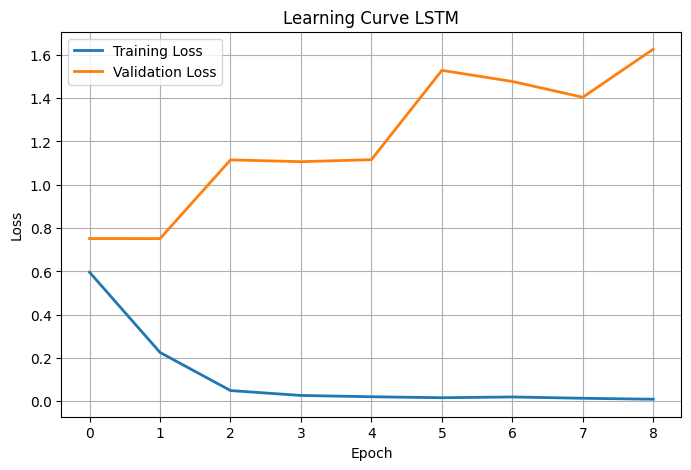

In [ ]:
import matplotlib.pyplot as plt

# ==========================================================
# Learning Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve LSTM")

plt.legend()

plt.grid(True)

plt.show()

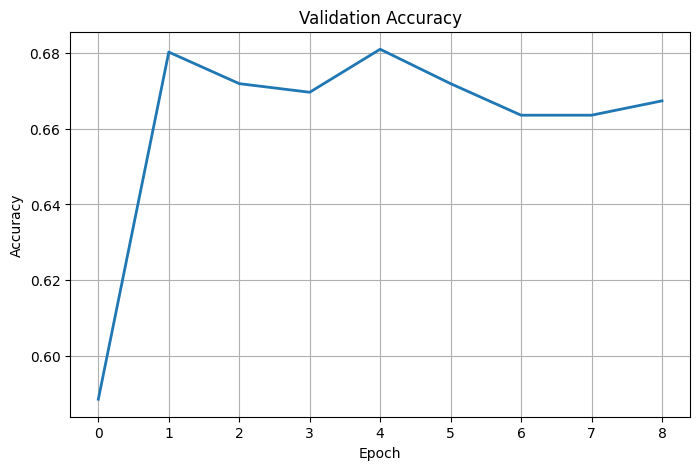

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["subset_accuracy"], linewidth=2)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

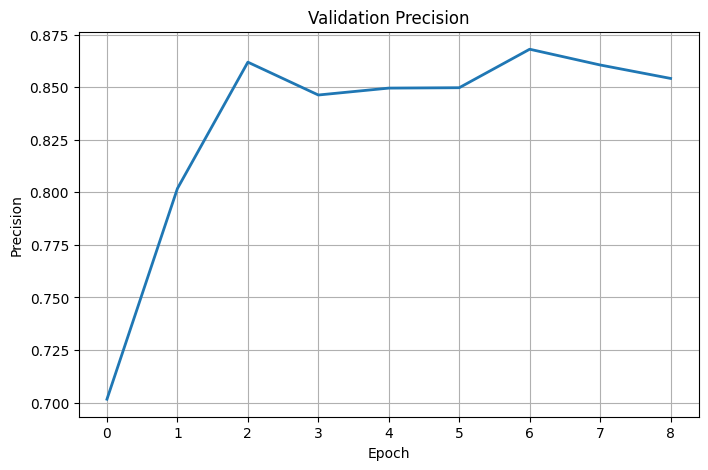

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["precision"], linewidth=2)

plt.title("Validation Precision")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

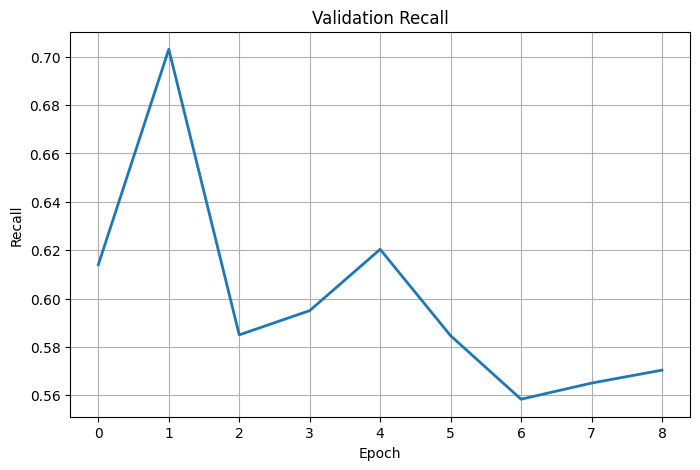

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["recall"], linewidth=2)

plt.title("Validation Recall")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

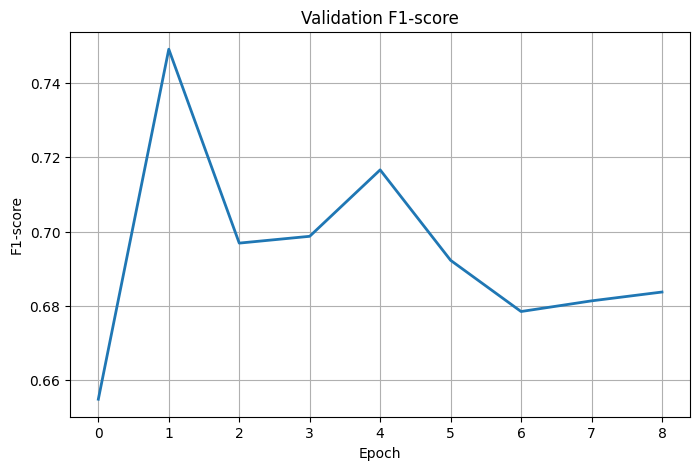

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["f1"], linewidth=2)

plt.title("Validation F1-score")

plt.xlabel("Epoch")

plt.ylabel("F1-score")

plt.grid(True)

plt.show()

# Prediksi data Test

In [ ]:
# ==========================================================
# Load Best Model dari Google Drive
# ==========================================================

model = LSTMClassifier(embedding_matrix).to(device)

model.load_state_dict(
    torch.load(
        f"{OUTPUT_PATH}/best_lstm_model.pth",
        map_location=device
    )
)

model.eval()

print("Best model berhasil dimuat dari Google Drive.")

Best model berhasil dimuat dari Google Drive.


In [ ]:
import numpy as np

# ==========================================================
# Testing
# ==========================================================

y_true = []
y_pred = []

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)
        labels = labels.to(device)

        outputs = model(sequences)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape)
print(y_pred.shape)

(2634, 2)
(2634, 2)


In [ ]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

subset_accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

hamming = hamming_loss(
    y_true,
    y_pred
)

print("="*40)
print("TEST EVALUATION")
print("="*40)

print(f"Subset Accuracy : {subset_accuracy:.4f}")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1-score  : {f1:.4f}")
print(f"Hamming Loss    : {hamming:.4f}")

TEST EVALUATION
Subset Accuracy : 0.6989
Macro Precision : 0.8224
Macro Recall    : 0.7082
Macro F1-score  : 0.7609
Hamming Loss    : 0.1794


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Hate Speech",
            "Abusive"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

 Hate Speech       0.79      0.66      0.72      1095
     Abusive       0.86      0.76      0.80      1021

   micro avg       0.82      0.71      0.76      2116
   macro avg       0.82      0.71      0.76      2116
weighted avg       0.82      0.71      0.76      2116
 samples avg       0.40      0.39      0.39      2116



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

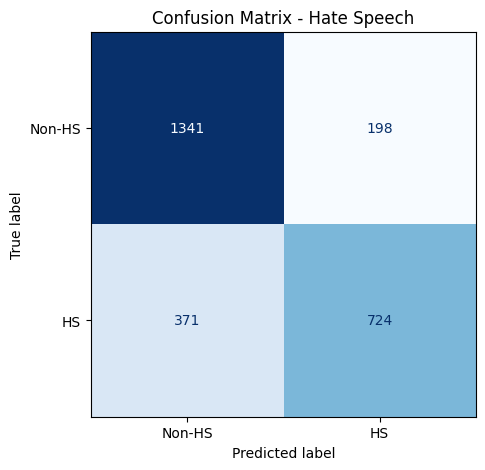

In [ ]:
# ==========================================================
# Confusion Matrix - Hate Speech
# ==========================================================

cm_hs = confusion_matrix(
    y_true[:, 0],
    y_pred[:, 0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hs,
    display_labels=["Non-HS", "HS"]
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    values_format="d"
)

plt.title("Confusion Matrix - Hate Speech")

plt.grid(False)

plt.show()

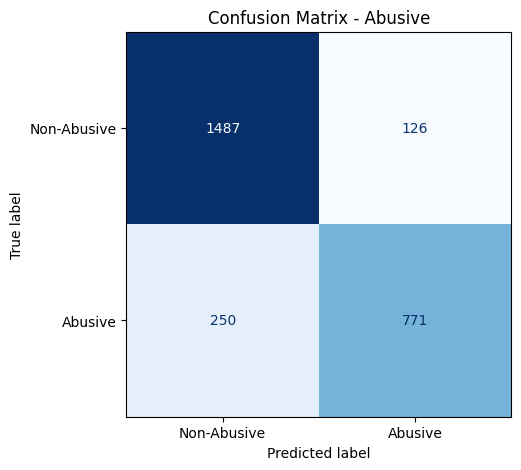

In [ ]:
# ==========================================================
# Confusion Matrix - Abusive
# ==========================================================

cm_abusive = confusion_matrix(
    y_true[:, 1],
    y_pred[:, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_abusive,
    display_labels=["Non-Abusive", "Abusive"]
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    values_format="d"
)

plt.title("Confusion Matrix - Abusive")

plt.grid(False)

plt.show()